# Chatbot Evaluation (notebook)

## Libraries

In [1]:
import sys
from pathlib import Path
sys.path.append("/Users/antoniooliveira/Documents/GitHub/IAPMEI-chatbot-v3")

sys.path.append(str(Path().resolve().parent))

import chatbot.chatbot as chatbot
import utils.utils as utils

import numpy as np
import pandas as pd
import json
from dotenv import load_dotenv
import nest_asyncio
from pathlib import Path

from openai import OpenAI
from langchain_openai import OpenAIEmbeddings

from datasets import Dataset

from ragas.llms import llm_factory
from ragas import evaluate
import os

import pandas as pd
import matplotlib.pyplot as plt


load_dotenv()
client = OpenAI()
nest_asyncio.apply()

**Control**

Default Values

- k = 10
- top_k = 10
- weight_dense = 0.5
- weight_sparse = 0.5
- rerank = False

In [ ]:
chunk_size = 600
chunk_overlap = 60
embeddings_type = "small"
k = 15
top_k = 15
weight_dense = 0.4
weight_sparse = 0.6
rerank = False

### Load Evaluation Dataset

In [3]:
with open("/Users/antoniooliveira/Documents/GitHub/IAPMEI-chatbot-v3/evaluation/evaluation_datasets/evaluation_dataset_v2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [4]:
eval_dataset = utils.json_to_documents(data)

### Load index and metadata

In [5]:
BASE_DIR = Path("/Users/antoniooliveira/Documents/GitHub/IAPMEI-chatbot-v3")

index_path = BASE_DIR / f"data/04_vectorized/{embeddings_type}/c{chunk_size}_{chunk_overlap}"

In [6]:
chatbot.set_vector_dir(index_path)
index, metadata = chatbot.load_faiss_index(chatbot.VECTOR_DIR)
bm25=chatbot.build_bm25(metadata)
print(f"Index and metadata loaded at {chatbot.VECTOR_DIR}")

Index and metadata loaded at /Users/antoniooliveira/Documents/GitHub/IAPMEI-chatbot-v3/data/04_vectorized/small/c600_60


**Fill loaded dataset with answers**

In [10]:
filename = f"eval_dataset_filled_{embeddings_type}_c{chunk_size}_{chunk_overlap}__{k}_{top_k}_{weight_dense}_{weight_sparse}_{rerank}_v2.json"
filepath = BASE_DIR / "evaluation/filled_evaluation_datasets" / filename

if not filepath.exists():
    
    eval_dataset = utils.populate_eval_dataset(
        eval_dataset, index, metadata, bm25,
        model="gpt-4o-mini",
        k=k,
        top_k=top_k,
        weight_dense=weight_dense,
        weight_sparse=weight_sparse,
        rerank=rerank
    )
    
    with open(filepath, "w") as f:
        json.dump(eval_dataset, f)

    
else:
    with open(filepath, "r") as f:
        eval_dataset = json.load(f)

In [11]:
times = [x["response_time"] for x in eval_dataset]

print("\nLatency stats:")
print(f"Mean:   {np.mean(times):.4f}s")
print(f"Median: {np.median(times):.4f}s")
print(f"P95:    {np.percentile(times,95):.4f}s")
print(f"P99:    {np.percentile(times,99):.4f}s")
print(f"Max:    {np.max(times):.4f}s")


Latency stats:
Mean:   4.8826s
Median: 5.0175s
P95:    7.9055s
P99:    8.7930s
Max:    8.8375s


### Evaluation

**Metric Selection**

In [12]:
# Prepare your dataset
dataset = Dataset.from_list(eval_dataset)
dataset = dataset.rename_columns({
    "question": "user_input",
    "bot_answer": "response",
    "answer": "reference"
})

In [13]:
# Create evaluator LLM
llm = llm_factory("gpt-3.5-turbo", provider="openai", 
                  client=client)

In [14]:
# Create embeddings via langchain_openai
embeddings = OpenAIEmbeddings(model=f"text-embedding-3-{embeddings_type}")

In [15]:
# Evaluate
result = evaluate(dataset, embeddings=embeddings, 
                  llm=llm, allow_nest_asyncio=True)

Evaluating:   0%|          | 0/140 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.

KeyboardInterrupt



KeyboardInterrupt: 

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


In [61]:
print(f"{filename}: \n\n{result}")

eval_dataset_filled_small_c400_0__15_15_0.5_0.5_False.json: 

{'answer_relevancy': 0.8185, 'context_precision': 0.9398, 'faithfulness': 0.8463, 'context_recall': 0.9095}


## Best Models Comparison

In [5]:
v1_400 = pd.read_csv('results/evaluation_results_small_c400_40__10_10_0.5_0.5_False.csv')
v2_400 = pd.read_csv('results/evaluation_results_small_c400_40__10_10_0.5_0.5_False_v2.csv')
v3_400 = pd.read_csv('results/evaluation_results_small_c400_40__10_10_0.5_0.5_False_v3.csv')
v4_400 = pd.read_csv('results/evaluation_results_small_c400_40__10_10_0.5_0.5_False_v4.csv')
v5_400 = pd.read_csv('results/evaluation_results_small_c400_40__10_10_0.5_0.5_False_v5.csv')

In [6]:
v1_600 = pd.read_csv('results/evaluation_results_small_c600_60__15_15_0.4_0.6_False.csv')
v2_600 = pd.read_csv('results/evaluation_results_small_c600_60__15_15_0.4_0.6_False_v2.csv')
v3_600 = pd.read_csv('results/evaluation_results_small_c600_60__15_15_0.4_0.6_False_v3.csv')
v4_600 = pd.read_csv('results/evaluation_results_small_c600_60__15_15_0.4_0.6_False_v4.csv')
v5_600 = pd.read_csv('results/evaluation_results_small_c600_60__15_15_0.4_0.6_False_v5.csv')

In [4]:
df_400 = [v1_400, v2_400, v3_400, v4_400, v5_400]
df_600 = [v1_600, v2_600, v3_600, v4_600, v5_600]

In [5]:
def compute_summary(dfs, label_suffix):
    metrics = [
        "answer_relevancy",
        "context_precision",
        "faithfulness",
        "context_recall"
    ]
    
    means = []
    
    for i, df in enumerate(dfs):
        df_means = df[metrics].mean()
        df_means["dataset"] = f"v{i+1}_{label_suffix}"
        df_means["version"] = f"v{i+1}"
        means.append(df_means)
        
    return pd.DataFrame(means)

In [6]:
summary_400 = compute_summary(df_400, "400")
summary_600 = compute_summary(df_600, "600")

In [7]:
summary_400

,answer_relevancy,context_precision,faithfulness,context_recall,dataset,version
0,0.871672,0.849905,0.891758,0.795238,v1_400,v1
1,0.875371,0.856000,0.854181,0.807143,v2_400,v2
2,0.903326,0.869092,0.848691,0.797619,v3_400,v3
3,0.883295,0.845269,0.818700,0.780952,v4_400,v4
4,0.864063,0.856607,0.830463,0.785714,v5_400,v5


In [126]:
summary_600

,answer_relevancy,context_precision,faithfulness,context_recall,dataset,version
0,0.885516,0.839348,0.863774,0.866667,v1_600,v1
1,0.806341,0.833741,0.850463,0.833333,v2_600,v2
2,0.819876,0.841597,0.851043,0.876190,v3_600,v3
3,0.808115,0.848370,0.853764,0.847619,v4_600,v4
4,0.812394,0.850906,0.820229,0.876190,v5_600,v5


In [8]:
summary_400 = summary_400.set_index("version")
summary_600 = summary_600.set_index("version")

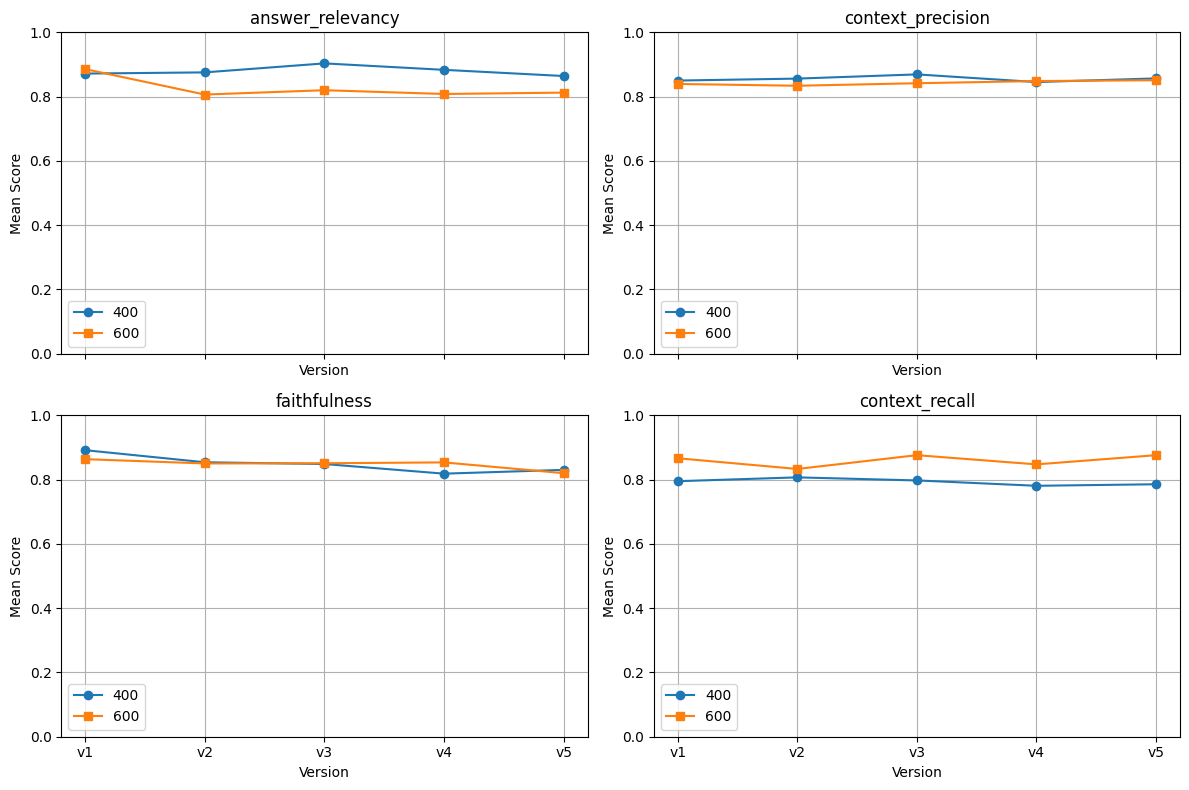

In [9]:
metrics = [
    "answer_relevancy",
    "context_precision",
    "faithfulness",
    "context_recall"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, metric in enumerate(metrics):
    
    axes[i].plot(summary_400.index, summary_400[metric],
                 marker='o', label="400")
    
    axes[i].plot(summary_600.index, summary_600[metric],
                 marker='s', label="600")
    
    axes[i].set_title(metric)
    axes[i].set_xlabel("Version")
    axes[i].set_ylabel("Mean Score")
    axes[i].set_ylim(0, 1) 
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [133]:
def compute_summary2(dfs, label_suffix):
    metrics = [
        "answer_relevancy",
        "context_precision",
        "faithfulness",
        "context_recall"
    ]
    
    summaries = []
    
    for i, df in enumerate(dfs):
        summary = {}
        
        for metric in metrics:
            summary[f"{metric}_mean"] = df[metric].mean()
            summary[f"{metric}_p25"] = df[metric].quantile(0.25)
            summary[f"{metric}_median"] = df[metric].quantile(0.50)
            summary[f"{metric}_p75"] = df[metric].quantile(0.75)
        
        summary["dataset"] = f"v{i+1}_{label_suffix}"
        summary["version"] = f"v{i+1}"
        
        summaries.append(summary)
        
    return pd.DataFrame(summaries)

In [134]:
summary_400_2 = compute_summary2(df_400, "400")
summary_600_2 = compute_summary2(df_600, "600")

In [138]:
summary_400_2.T

,0,1,2,3,4
answer_relevancy_mean,0.871672,0.875371,0.903326,0.883295,0.864063
answer_relevancy_p25,0.808476,0.791696,0.831904,0.836662,0.818397
answer_relevancy_median,0.867466,0.885329,0.936028,0.903974,0.885269
answer_relevancy_p75,0.997284,0.999997,0.999997,0.996095,0.984727
context_precision_mean,0.849905,0.856,0.869092,0.845269,0.856607
context_precision_p25,0.848193,0.828051,0.842665,0.828051,0.831997
context_precision_median,0.95,0.95,0.976543,0.946781,0.937925
context_precision_p75,1.0,1.0,1.0,1.0,1.0
faithfulness_mean,0.891758,0.854181,0.848691,0.8187,0.830463
faithfulness_p25,0.857143,0.8,0.745726,0.679487,0.75


In [137]:
summary_600_2.T

,0,1,2,3,4
answer_relevancy_mean,0.885516,0.806341,0.819876,0.808115,0.812394
answer_relevancy_p25,0.84143,0.780093,0.798554,0.762157,0.781362
answer_relevancy_median,0.905413,0.8532,0.857914,0.859458,0.859482
answer_relevancy_p75,0.999994,0.947089,0.974503,0.974515,0.947316
context_precision_mean,0.839348,0.833741,0.841597,0.84837,0.850906
context_precision_p25,0.832307,0.808808,0.826159,0.834776,0.837288
context_precision_median,0.911793,0.910552,0.941667,0.941667,0.923578
context_precision_p75,0.975549,0.992687,0.98994,0.987193,0.980416
faithfulness_mean,0.863774,0.850463,0.851043,0.853764,0.820229
faithfulness_p25,0.777778,0.769231,0.75,0.804762,0.732143


In [10]:
df_400_all = pd.concat(df_400, ignore_index=True)
df_600_all = pd.concat(df_600, ignore_index=True)

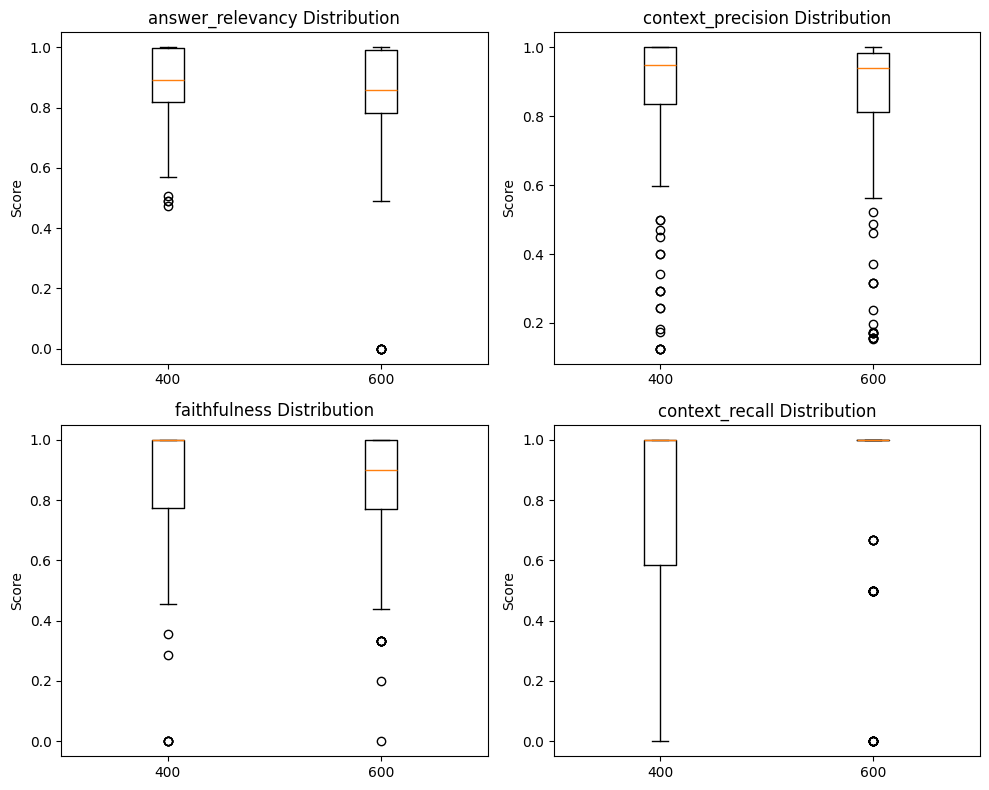

In [11]:
metrics = [
    "answer_relevancy",
    "context_precision",
    "faithfulness",
    "context_recall"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()  # makes indexing easier

for i, metric in enumerate(metrics):
    axes[i].boxplot(
        [df_400_all[metric], df_600_all[metric]],
        tick_labels=["400", "600"]
    )
    
    axes[i].set_title(f"{metric} Distribution")
    axes[i].set_ylabel("Score")

plt.tight_layout()
plt.show()